# C5: BiLSTM + Deg loss + 4-parameter ECM branch

**Adds a new configuration to the existing factorial.**

C5 uses ONLY the 4 degradation-relevant ECM parameters:
- `R_ohm` (index 1) → Conductivity Loss (CL)
- `R_ct1` (index 2) → Lithium Inventory Loss (LLI)
- `R_ct2` (index 5) → Lithium Inventory Loss (LLI)
- `Z_w`   (index 8) → Loss of Active Material (LAM)

Drops L, Q1, α1, Q2, α2 — these are fitting artifacts that add noise without degradation information.

**Run AFTER `bilstm_complete.ipynb` in the same kernel, OR reload from disk.**

**Runtime: ~30 min on CPU.**

## 1. Reload previous results (if kernel restarted)

In [21]:
import os, random, copy, time, warnings, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.stats import chi2, spearmanr

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

g = torch.Generator(); g.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── Load dataset ───
data = np.load('leonardi_final.npz', allow_pickle=True)
X_seq_np      = data['X_seq'].astype(np.float32)
X_tab_np      = data['X_tab'].astype(np.float32)
y_SoC_norm_np = data['y_SoC_norm'].astype(np.float32)
y_SoH_norm_np = data['y_SoH_norm'].astype(np.float32)
cell_ids  = data['cell_ids']
protocols = data['protocols']
cycles    = data['cycles']

# ─── Extract 4-param ECM subset ───
# X_tab columns: [L, R_ohm, R_ct1, Q1, alpha1, R_ct2, Q2, alpha2, Z_w]
#                  0    1      2     3     4       5     6     7      8
ECM4_INDICES = [1, 2, 5, 8]  # R_ohm, R_ct1, R_ct2, Z_w
ECM4_NAMES = ['$R_{ohm}$', '$R_{ct1}$', '$R_{ct2}$', '$Z_w$']
ECM4_PHYSICS = ['CL (SEI)', 'LLI (anode)', 'LLI (cathode)', 'LAM (diffusion)']
X_tab4_np = X_tab_np[:, ECM4_INDICES]  # (488, 4)
print(f"4-param ECM subset: {X_tab4_np.shape}")
print(f"  Parameters: {ECM4_NAMES}")
print(f"  Physics:    {ECM4_PHYSICS}")

# ─── Compute degradation labels ───
CL_raw  = np.zeros(len(X_tab_np), dtype=np.float32)
LLI_raw = np.zeros(len(X_tab_np), dtype=np.float32)
LAM_raw = np.zeros(len(X_tab_np), dtype=np.float32)
for cid in np.unique(cell_ids):
    mask = (cell_ids == cid); cycs = cycles[mask]
    c0 = mask & (cycles == cycs.min())
    R0  = X_tab_np[c0,1].mean(); R1_0 = X_tab_np[c0,2].mean()
    R2_0 = X_tab_np[c0,5].mean(); Z0 = X_tab_np[c0,8].mean()
    CL_raw[mask]  = (X_tab_np[mask,1]-R0)/(R0+1e-10)*100
    LLI_raw[mask] = ((X_tab_np[mask,2]-R1_0)+(X_tab_np[mask,5]-R2_0))/(R1_0+R2_0+1e-10)*100
    LAM_raw[mask] = (X_tab_np[mask,8]-Z0)/(Z0+1e-10)*100
CL_raw  = np.clip(CL_raw,  -10,  50)
LLI_raw = np.clip(LLI_raw, -10, 100)
LAM_raw = np.clip(LAM_raw, -10, 100)
y_deg_np = np.stack([CL_raw, LLI_raw, LAM_raw], axis=1)
y_deg_norm_np = np.zeros_like(y_deg_np)
deg_stats = {}
for i, name in enumerate(['CL', 'LLI', 'LAM']):
    lo, hi = y_deg_np[:,i].min(), y_deg_np[:,i].max()
    rng = hi - lo if hi != lo else 1.0
    y_deg_norm_np[:,i] = (y_deg_np[:,i] - lo) / rng
    deg_stats[name] = {'min': lo, 'max': hi, 'range': rng}

# ─── Load C1-C4 results ───
SAVE_DIR = './bilstm_full_results'
try:
    with open(os.path.join(SAVE_DIR, 'all_results.pkl'), 'rb') as f:
        saved = pickle.load(f)
    all_configs = saved['all_configs']
    config_labels = saved['config_labels']
    print(f"\nLoaded C1-C4 results from {SAVE_DIR}")
    for k, v in config_labels.items():
        mae = np.mean([all_configs[k][c]['SoC']['MAE'] for c in range(1,9)])
        print(f"  {k}: {v:<25} Overall MAE_SoC = {mae:.2f}%")
except FileNotFoundError:
    print("WARNING: C1-C4 results not found — run bilstm_complete.ipynb first")
    all_configs = {}
    config_labels = {}

id_cells, ood_cells = [1,2,3,4], [5,6,7,8]
print(f"\nDataset: {len(y_SoC_norm_np)} samples, device: {device}")

4-param ECM subset: (488, 4)
  Parameters: ['$R_{ohm}$', '$R_{ct1}$', '$R_{ct2}$', '$Z_w$']
  Physics:    ['CL (SEI)', 'LLI (anode)', 'LLI (cathode)', 'LAM (diffusion)']

Loaded C1-C4 results from ./bilstm_full_results
  C1: BiLSTM-only               Overall MAE_SoC = 2.87%
  C2: BiLSTM + ECM              Overall MAE_SoC = 6.42%
  C3: BiLSTM + Deg loss         Overall MAE_SoC = 2.35%
  C4: BiLSTM + ECM + Deg loss   Overall MAE_SoC = 7.70%

Dataset: 488 samples, device: cpu


## 2. C5 architecture — BiLSTM + 4-param ECM + Deg head

Same as C4 but the MLPBranch takes 4 inputs instead of 9.
Only the degradation-relevant ECM parameters enter the model.

In [22]:
class EISDataset5(Dataset):
    """Returns (X_seq, X_tab4, y_SoC, y_SoH, y_deg)."""
    def __init__(self, X_seq, X_tab4, y_SoC, y_SoH, y_deg):
        self.X_seq, self.X_tab4 = X_seq, X_tab4
        self.y_SoC, self.y_SoH, self.y_deg = y_SoC, y_SoH, y_deg
    def __len__(self): return len(self.y_SoC)
    def __getitem__(self, i):
        return self.X_seq[i], self.X_tab4[i], self.y_SoC[i], self.y_SoH[i], self.y_deg[i]


class LSTMBranch(nn.Module):
    def __init__(self, in_channels=3, d_model=64, hidden_size=96,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=hidden_size,
                            num_layers=n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0,
                            bidirectional=True)
        self.output_proj = nn.Linear(hidden_size * 2, d_model)
        self.dropout = nn.Dropout(p=dropout)
    def forward(self, x):
        x = self.input_proj(x); x, _ = self.lstm(x)
        x = x.mean(dim=1); x = self.output_proj(x)
        return self.dropout(x)


class MLPBranch4(nn.Module):
    """Dense MLP over 4 degradation-relevant ECM parameters only."""
    def __init__(self, in_features=4, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(p=dropout))
    def forward(self, x): return self.net(x)


class BiLSTM_C5(nn.Module):
    """
    C5: BiLSTM + 4-param ECM + Degradation auxiliary head.

    Branch A: BiLSTM over raw EIS spectrum (B, 51, 3) → (B, 64)
    Branch B: MLPBranch4 over [R_ohm, R_ct1, R_ct2, Z_w] (B, 4) → (B, 64)
    Fusion:   concat → (B, 128)
    Heads:    SoC (2), SoH (2), Deg (3)
    """
    def __init__(self, d_model=64, hidden_size=96, n_layers=2, dropout=0.1):
        super().__init__()
        self.branch_a = LSTMBranch(3, d_model, hidden_size, n_layers, dropout)
        self.branch_b = MLPBranch4(4, d_model, dropout)
        fin = d_model * 2

        self.fusion_SoC = nn.Sequential(
            nn.Linear(fin, d_model), nn.LayerNorm(d_model),
            nn.GELU(), nn.Dropout(p=dropout),
            nn.Linear(d_model, d_model//2), nn.LayerNorm(d_model//2),
            nn.GELU(), nn.Dropout(p=dropout))
        self.fusion_SoH = nn.Sequential(
            nn.Linear(fin, d_model), nn.LayerNorm(d_model),
            nn.GELU(), nn.Dropout(p=dropout))

        self.head_SoC = nn.Linear(d_model//2, 2)
        self.head_SoH = nn.Linear(d_model, 2)
        self.head_deg = nn.Linear(fin, 3)  # CL, LLI, LAM

        with torch.no_grad():
            self.head_SoC.bias[1] = -3.0
            self.head_SoH.bias[1] = -3.0

    def forward(self, x_seq, x_tab4):
        h_a = self.branch_a(x_seq)
        h_b = self.branch_b(x_tab4)
        h = torch.cat([h_a, h_b], dim=-1)

        out_SoC = self.head_SoC(self.fusion_SoC(h))
        out_SoH = self.head_SoH(self.fusion_SoH(h))
        mu_SoC = torch.sigmoid(out_SoC[:,0])
        ls_SoC = out_SoC[:,1]
        mu_SoH = torch.sigmoid(out_SoH[:,0]) * 0.23 + 0.77
        ls_SoH = out_SoH[:,1]
        deg = torch.sigmoid(self.head_deg(h))
        return mu_SoC, ls_SoC, mu_SoH, ls_SoH, deg


n_c5 = sum(p.numel() for p in BiLSTM_C5().parameters())
print(f"C5 params: {n_c5:,}")
print(f"  (C4 with 9-param ECM would be slightly more due to Linear(9→64) vs Linear(4→64))")

C5 params: 383,975
  (C4 with 9-param ECM would be slightly more due to Linear(9→64) vs Linear(4→64))


## 3. Loss + MC Dropout + training utilities

In [23]:
def nll_loss(mu, log_sigma, y):
    ls = torch.clamp(log_sigma, -5.0, 2.0)
    return (ls + 0.5 * torch.exp(-2.0*ls) * (y-mu)**2).mean()

def total_loss(mu_soc, ls_soc, mu_soh, ls_soh, y_soc, y_soh,
               deg_pred=None, y_deg=None, lam=0.3,
               sigma_penalty_soc=0.10, sigma_penalty_soh=0.05,
               mae_weight=0.5, lam_deg=0.5):
    ls_soc = torch.clamp(ls_soc, -6.0, 2.0)
    ls_soh = torch.clamp(ls_soh, -6.0, 2.0)
    l_soc = nll_loss(mu_soc, ls_soc, y_soc)
    l_soh = nll_loss(mu_soh, ls_soh, y_soh)
    mae_soc = torch.abs(mu_soc-y_soc).mean()
    mae_soh = torch.abs(mu_soh-y_soh).mean()
    penalty = sigma_penalty_soc*ls_soc.mean() + sigma_penalty_soh*ls_soh.mean()
    total = l_soc + lam*l_soh + mae_weight*(mae_soc+lam*mae_soh) + penalty
    if deg_pred is not None and y_deg is not None:
        total = total + lam_deg * nn.functional.mse_loss(deg_pred, y_deg)
    return total, l_soc.item(), l_soh.item()


def mc_predict(model, x_seq, x_tab, T=50):
    model.train()
    mus_soc, mus_soh, vars_soc, vars_soh, degs = [], [], [], [], []
    with torch.no_grad():
        for _ in range(T):
            mu_s, ls_s, mu_h, ls_h, deg = model(x_seq, x_tab)
            ls_s = torch.clamp(ls_s, -6.0, 2.0)
            ls_h = torch.clamp(ls_h, -6.0, 2.0)
            mus_soc.append(mu_s); mus_soh.append(mu_h)
            vars_soc.append(torch.exp(2.0*ls_s))
            vars_soh.append(torch.exp(2.0*ls_h))
            if deg is not None: degs.append(deg)
    mus_soc = torch.stack(mus_soc); mus_soh = torch.stack(mus_soh)
    vars_soc = torch.stack(vars_soc); vars_soh = torch.stack(vars_soh)
    epi_soc = mus_soc.var(0); epi_soh = mus_soh.var(0)
    alea_soc = vars_soc.mean(0); alea_soh = vars_soh.mean(0)
    r = {
        'mu_SoC': mus_soc.mean(0), 'mu_SoH': mus_soh.mean(0),
        'sigma_epi_SoC': epi_soc.sqrt(), 'sigma_epi_SoH': epi_soh.sqrt(),
        'sigma_alea_SoC': alea_soc.sqrt(), 'sigma_alea_SoH': alea_soh.sqrt(),
        'sigma_total_SoC': (epi_soc+alea_soc).sqrt(),
        'sigma_total_SoH': (epi_soh+alea_soh).sqrt(),
    }
    if degs: r['deg_pred'] = torch.stack(degs).mean(0)
    return r


def loco_split(cell_ids, test_cell):
    m = (cell_ids == test_cell); return ~m, m


def scale_and_build_c5(X_seq, X_tab4, y_SoC, y_SoH, y_deg_norm,
                       train_mask, test_mask, batch_size=32):
    """Scale with 4-param ECM instead of 9."""
    sc_seq = StandardScaler(); sc_seq.fit(X_seq[train_mask].reshape(-1,3))
    def tx(X):
        n = X.shape[0]
        return sc_seq.transform(X.reshape(-1,3)).reshape(n,51,3).astype(np.float32)
    Xs_tr, Xs_te = tx(X_seq[train_mask]), tx(X_seq[test_mask])

    sc_tab = StandardScaler(); sc_tab.fit(X_tab4[train_mask])
    Xt_tr = sc_tab.transform(X_tab4[train_mask]).astype(np.float32)
    Xt_te = sc_tab.transform(X_tab4[test_mask]).astype(np.float32)

    ds_tr = EISDataset5(torch.tensor(Xs_tr), torch.tensor(Xt_tr),
                        torch.tensor(y_SoC[train_mask]),
                        torch.tensor(y_SoH[train_mask]),
                        torch.tensor(y_deg_norm[train_mask]))
    ds_te = EISDataset5(torch.tensor(Xs_te), torch.tensor(Xt_te),
                        torch.tensor(y_SoC[test_mask]),
                        torch.tensor(y_SoH[test_mask]),
                        torch.tensor(y_deg_norm[test_mask]))
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,
                       worker_init_fn=seed_worker, generator=g)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False,
                       worker_init_fn=seed_worker, generator=g)
    return dl_tr, dl_te, sc_seq, sc_tab


class EarlyStopping:
    def __init__(self, patience=25, min_delta=1e-4):
        self.patience=patience; self.min_delta=min_delta
        self.best_loss=np.inf; self.counter=0; self.best_state=None
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss=val_loss; self.counter=0
            self.best_state=copy.deepcopy(model.state_dict())
        else: self.counter += 1
        return self.counter >= self.patience
    def restore(self, model):
        if self.best_state: model.load_state_dict(self.best_state)

print("All utilities defined")

All utilities defined


## 4. Train C5 — 8-fold LOCO (~30 min)

In [24]:
print("=" * 65)
print("C5: BiLSTM + 4-param ECM (R_ohm, R_ct1, R_ct2, Z_w) + Deg loss")
print("=" * 65)

c5_results = {}
c5_models = {}
c5_scalers = {}

for cell_id in range(1, 9):
    prot = protocols[cell_ids == cell_id][0]
    n_test = (cell_ids == cell_id).sum()
    print(f"\nFold {cell_id}/8 — Cell {cell_id:02d} ({prot}, {n_test} samples)")
    t0 = time.time()

    tr_mask, te_mask = loco_split(cell_ids, cell_id)
    dl_tr, dl_te, sc_seq, sc_tab = scale_and_build_c5(
        X_seq_np, X_tab4_np, y_SoC_norm_np, y_SoH_norm_np,
        y_deg_norm_np, tr_mask, te_mask)

    model = BiLSTM_C5().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = None
    stopper = EarlyStopping(patience=25)
    warmup_epochs = 10

    for epoch in range(1, 201):
        if epoch <= warmup_epochs:
            for pg in opt.param_groups:
                pg['lr'] = 1e-3 * (epoch / warmup_epochs)
        if epoch == warmup_epochs + 1 and scheduler is None:
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)

        # Train
        model.train()
        for x_seq, x_tab4, y_soc, y_soh, y_deg in dl_tr:
            x_seq = x_seq.to(device); x_tab4 = x_tab4.to(device)
            y_soc = y_soc.to(device); y_soh = y_soh.to(device)
            y_deg = y_deg.to(device)
            mu_s, ls_s, mu_h, ls_h, deg = model(x_seq, x_tab4)
            loss, _, _ = total_loss(mu_s, ls_s, mu_h, ls_h, y_soc, y_soh,
                                    deg_pred=deg, y_deg=y_deg, lam=0.3)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()

        # Val
        model.eval(); val_losses = []
        with torch.no_grad():
            for x_seq, x_tab4, y_soc, y_soh, y_deg in dl_te:
                x_seq = x_seq.to(device); x_tab4 = x_tab4.to(device)
                y_soc = y_soc.to(device); y_soh = y_soh.to(device)
                y_deg = y_deg.to(device)
                mu_s, ls_s, mu_h, ls_h, deg = model(x_seq, x_tab4)
                loss, _, _ = total_loss(mu_s, ls_s, mu_h, ls_h, y_soc, y_soh,
                                        deg_pred=deg, y_deg=y_deg, lam=0.3)
                val_losses.append(loss.item())
        va = np.mean(val_losses)
        if scheduler is not None: scheduler.step(va)

        if epoch > warmup_epochs:
            if stopper.step(va, model): break
        else:
            if va < stopper.best_loss - stopper.min_delta:
                stopper.best_loss = va
                stopper.best_state = copy.deepcopy(model.state_dict())

    stopper.restore(model)
    c5_models[cell_id] = model
    c5_scalers[cell_id] = {'seq': sc_seq, 'tab': sc_tab}

    # ─── Evaluate with MC Dropout ───
    mask = (cell_ids == cell_id)
    Xs = sc_seq.transform(X_seq_np[mask].reshape(-1,3))\
               .reshape(-1,51,3).astype(np.float32)
    Xt = sc_tab.transform(X_tab4_np[mask]).astype(np.float32)
    preds = mc_predict(model, torch.tensor(Xs).to(device),
                       torch.tensor(Xt).to(device), T=50)
    preds_np = {k: v.cpu().numpy() for k, v in preds.items()}

    z = 1.645
    mu_soc = preds_np['mu_SoC']*100; y_soc = y_SoC_norm_np[mask]*100
    mu_soh = preds_np['mu_SoH']*100; y_soh = y_SoH_norm_np[mask]*100
    sig_soc = preds_np['sigma_total_SoC']*100
    sig_soh = preds_np['sigma_total_SoH']*100

    cell_result = {
        'preds': preds_np, 'mask': mask, 'prot': prot,
        'SoC': {
            'MAE': np.mean(np.abs(mu_soc-y_soc)),
            'RMSE': np.sqrt(np.mean((mu_soc-y_soc)**2)),
            'PICP': np.mean((y_soc>=mu_soc-z*sig_soc)&(y_soc<=mu_soc+z*sig_soc)),
            'sigma_epi': np.mean(preds_np['sigma_epi_SoC'])*100,
            'sigma_alea': np.mean(preds_np['sigma_alea_SoC'])*100,
        },
        'SoH': {
            'MAE': np.mean(np.abs(mu_soh-y_soh)),
            'RMSE': np.sqrt(np.mean((mu_soh-y_soh)**2)),
            'PICP': np.mean((y_soh>=mu_soh-z*sig_soh)&(y_soh<=mu_soh+z*sig_soh)),
            'sigma_epi': np.mean(preds_np['sigma_epi_SoH'])*100,
            'sigma_alea': np.mean(preds_np['sigma_alea_SoH'])*100,
        },
    }
    # Degradation metrics
    if 'deg_pred' in preds_np:
        deg_true = y_deg_np[mask]
        deg_pred_norm = preds_np['deg_pred']
        deg_pred_raw = np.zeros_like(deg_pred_norm)
        for i, nm in enumerate(['CL','LLI','LAM']):
            s = deg_stats[nm]
            deg_pred_raw[:,i] = deg_pred_norm[:,i]*s['range']+s['min']
        cell_result['Deg'] = {}
        for i, nm in enumerate(['CL','LLI','LAM']):
            cell_result['Deg'][nm] = {
                'MAE': np.mean(np.abs(deg_pred_raw[:,i]-deg_true[:,i])),
            }
    c5_results[cell_id] = cell_result
    elapsed = time.time() - t0
    deg_str = ''
    if 'Deg' in cell_result:
        deg_str = (f"  CL={cell_result['Deg']['CL']['MAE']:.1f}% "
                   f"LLI={cell_result['Deg']['LLI']['MAE']:.1f}% "
                   f"LAM={cell_result['Deg']['LAM']['MAE']:.1f}%")
    print(f"  {elapsed:.0f}s | MAE_SoC={cell_result['SoC']['MAE']:.2f}%  "
          f"MAE_SoH={cell_result['SoH']['MAE']:.2f}%  "
          f"PICP_SoC={cell_result['SoC']['PICP']:.3f}{deg_str}")

print("\nC5 training complete")

C5: BiLSTM + 4-param ECM (R_ohm, R_ct1, R_ct2, Z_w) + Deg loss

Fold 1/8 — Cell 01 (AP1, 60 samples)
  142s | MAE_SoC=2.29%  MAE_SoH=1.08%  PICP_SoC=0.983  CL=1.3% LLI=5.2% LAM=3.0%

Fold 2/8 — Cell 02 (AP1, 60 samples)
  142s | MAE_SoC=1.80%  MAE_SoH=0.98%  PICP_SoC=1.000  CL=0.4% LLI=6.5% LAM=2.8%

Fold 3/8 — Cell 03 (AP2, 48 samples)
  50s | MAE_SoC=6.87%  MAE_SoH=1.39%  PICP_SoC=1.000  CL=1.0% LLI=6.3% LAM=8.7%

Fold 4/8 — Cell 04 (AP2, 60 samples)
  155s | MAE_SoC=3.43%  MAE_SoH=1.12%  PICP_SoC=0.983  CL=0.6% LLI=5.3% LAM=3.5%

Fold 5/8 — Cell 05 (AP3, 45 samples)
  30s | MAE_SoC=13.46%  MAE_SoH=2.16%  PICP_SoC=0.844  CL=1.4% LLI=19.8% LAM=14.1%

Fold 6/8 — Cell 06 (AP3, 45 samples)
  65s | MAE_SoC=11.04%  MAE_SoH=2.50%  PICP_SoC=0.844  CL=1.2% LLI=8.0% LAM=10.5%

Fold 7/8 — Cell 07 (AP4, 85 samples)
  31s | MAE_SoC=9.78%  MAE_SoH=2.34%  PICP_SoC=1.000  CL=1.1% LLI=13.1% LAM=9.0%

Fold 8/8 — Cell 08 (AP4, 85 samples)
  52s | MAE_SoC=8.88%  MAE_SoH=1.47%  PICP_SoC=0.965  CL=0.9% LL

## 5. Merge C5 into existing results + save

In [25]:
# Add C5 to the results dict
all_configs['C5'] = c5_results
config_labels['C5'] = 'BiLSTM + 4-ECM + Deg'

# Save updated results
SAVE_DIR = './bilstm_full_results'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save C5 models
cfg_dir = os.path.join(SAVE_DIR, 'C5')
os.makedirs(cfg_dir, exist_ok=True)
for cid in range(1, 9):
    torch.save(c5_models[cid].state_dict(),
               os.path.join(cfg_dir, f'model_cell{cid:02d}.pt'))
with open(os.path.join(cfg_dir, 'scalers.pkl'), 'wb') as f:
    pickle.dump(c5_scalers, f)

# Save updated all_results
with open(os.path.join(SAVE_DIR, 'all_results.pkl'), 'wb') as f:
    pickle.dump({
        'all_configs': all_configs,
        'config_labels': config_labels,
        'deg_stats': deg_stats,
    }, f)

print(f"Saved C5 models to {cfg_dir}/")
print(f"Updated all_results.pkl with {len(all_configs)} configs:")
for k, v in config_labels.items():
    mae = np.mean([all_configs[k][c]['SoC']['MAE'] for c in range(1,9)])
    print(f"  {k}: {v:<28} Overall MAE_SoC = {mae:.2f}%")

Saved C5 models to ./bilstm_full_results/C5/
Updated all_results.pkl with 5 configs:
  C1: BiLSTM-only                  Overall MAE_SoC = 2.87%
  C2: BiLSTM + ECM                 Overall MAE_SoC = 6.42%
  C3: BiLSTM + Deg loss            Overall MAE_SoC = 2.35%
  C4: BiLSTM + ECM + Deg loss      Overall MAE_SoC = 7.70%
  C5: BiLSTM + 4-ECM + Deg         Overall MAE_SoC = 7.19%


## 6. Full comparison table (C1–C5)

In [26]:
def agg(results, cells, target, key):
    return np.mean([results[c][target][key] for c in cells])

print("=" * 100)
print("FULL FACTORIAL COMPARISON (C1–C5)")
print("=" * 100)
print(f"\n{'Config':<30} {'Split':<10} {'MAE_SoC':>10} {'PICP_SoC':>10} "
      f"{'sig_epi':>10} {'MAE_SoH':>10} {'PICP_SoH':>10}")
print("-" * 100)

for key in ['C1','C2','C3','C4','C5']:
    if key not in all_configs: continue
    res = all_configs[key]
    for sn, sc in [('In-dist',id_cells),('OOD',ood_cells),('Overall',list(range(1,9)))]:
        print(f"  {config_labels[key]:<28} {sn:<10} "
              f"{agg(res,sc,'SoC','MAE'):>9.2f}% "
              f"{agg(res,sc,'SoC','PICP'):>10.3f} "
              f"{agg(res,sc,'SoC','sigma_epi'):>9.2f}% "
              f"{agg(res,sc,'SoH','MAE'):>9.2f}% "
              f"{agg(res,sc,'SoH','PICP'):>10.3f}")
    print()

# Degradation accuracy
print("\nDEGRADATION PREDICTION ACCURACY")
print("-" * 60)
for key in ['C3','C4','C5']:
    if key not in all_configs: continue
    res = all_configs[key]
    print(f"  {config_labels[key]}:")
    for dn in ['CL','LLI','LAM']:
        mae = np.mean([res[c]['Deg'][dn]['MAE'] for c in range(1,9)])
        print(f"    {dn}: {mae:.2f}% MAE")

# Epistemic ratios
print("\nEPISTEMIC RATIOS (Gap 5)")
print("-" * 60)
for key in ['C1','C2','C3','C4','C5']:
    if key not in all_configs: continue
    res = all_configs[key]
    ie = np.mean([res[c]['SoC']['sigma_epi'] for c in id_cells])
    oe = np.mean([res[c]['SoC']['sigma_epi'] for c in [5,6]])
    r = oe/ie if ie > 0 else 0
    print(f"  {config_labels[key]:<28}: ratio = {r:.2f}x")

FULL FACTORIAL COMPARISON (C1–C5)

Config                         Split         MAE_SoC   PICP_SoC    sig_epi    MAE_SoH   PICP_SoH
----------------------------------------------------------------------------------------------------
  BiLSTM-only                  In-dist         0.66%      0.992      1.44%      0.54%      0.991
  BiLSTM-only                  OOD             5.07%      0.918      2.60%      1.83%      0.756
  BiLSTM-only                  Overall         2.87%      0.955      2.02%      1.18%      0.873

  BiLSTM + ECM                 In-dist         3.29%      1.000      2.75%      1.24%      0.886
  BiLSTM + ECM                 OOD             9.56%      0.934      5.22%      2.14%      0.767
  BiLSTM + ECM                 Overall         6.42%      0.967      3.99%      1.69%      0.827

  BiLSTM + Deg loss            In-dist         0.47%      1.000      1.33%      0.49%      0.992
  BiLSTM + Deg loss            OOD             4.24%      0.921      2.21%      1.52% 

## 7. Figure — 5-way comparison (C1–C5)

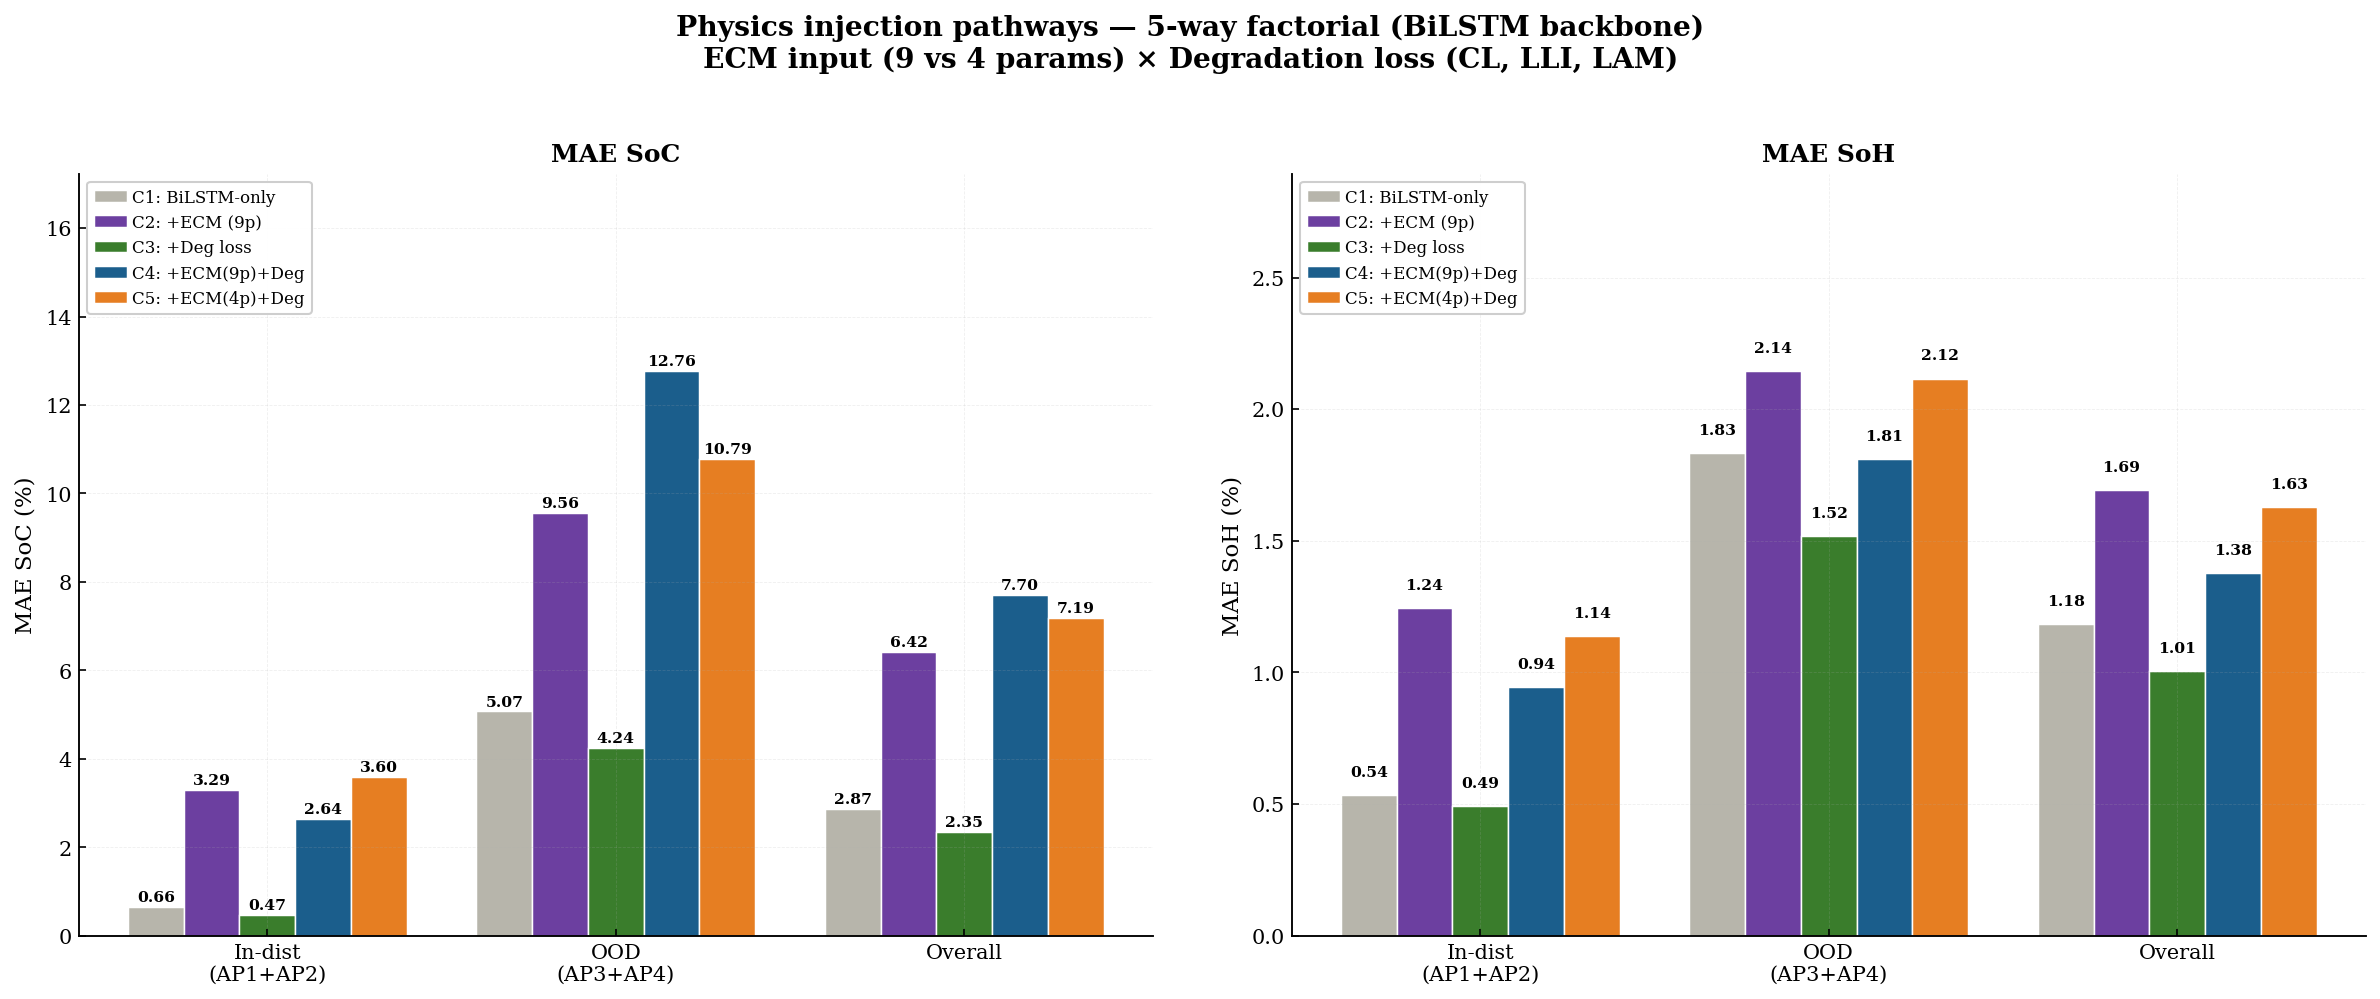

5-way factorial figure saved


In [27]:
plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'axes.linewidth': 0.9,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9, 'legend.framealpha': 0.95,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.20, 'grid.linestyle': '--',
})

FIG_DIR = './figures_bilstm_publication'
os.makedirs(FIG_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle('Physics injection pathways — 5-way factorial (BiLSTM backbone)\n'
             'ECM input (9 vs 4 params) × Degradation loss (CL, LLI, LAM)',
             fontsize=13.5, fontweight='bold', y=1.02)

sn = ['In-dist\n(AP1+AP2)', 'OOD\n(AP3+AP4)', 'Overall']
sg = [id_cells, ood_cells, list(range(1,9))]

bk = ['C1','C2','C3','C4','C5']
bl = ['C1: BiLSTM-only', 'C2: +ECM (9p)', 'C3: +Deg loss',
      'C4: +ECM(9p)+Deg', 'C5: +ECM(4p)+Deg']
bc = ['#B7B5AB', '#6C3FA0', '#3A7D2C', '#1B5E8C', '#E67E22']
bk_present = [k for k in bk if k in all_configs]
bl_present = [bl[i] for i, k in enumerate(bk) if k in all_configs]
bc_present = [bc[i] for i, k in enumerate(bk) if k in all_configs]

x = np.arange(len(sn))
n_bars = len(bk_present)
w = 0.80 / n_bars

for ax, tgt in zip(axes, ['SoC', 'SoH']):
    for i, (key, lbl, col) in enumerate(zip(bk_present, bl_present, bc_present)):
        res = all_configs[key]
        vals = [agg(res, s, tgt, 'MAE') for s in sg]
        offset = (i - (n_bars-1)/2) * w
        bars = ax.bar(x + offset, vals, w, color=col,
                      edgecolor='white', lw=0.7, label=lbl)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.06,
                    f'{v:.2f}', ha='center', va='bottom',
                    fontsize=7.5, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(sn, fontsize=10)
    ax.set_ylabel(f'MAE {tgt} (%)'); ax.set_title(f'MAE {tgt}')
    ax.legend(loc='upper left', fontsize=8, handletextpad=0.3)
    av = [agg(all_configs[k], s, tgt, 'MAE')
          for k in bk_present for s in sg]
    ax.set_ylim(0, max(av)*1.35)

fig.tight_layout(w_pad=3)
fig.savefig(f'{FIG_DIR}/F6_factorial_5way.pdf')
fig.savefig(f'{FIG_DIR}/F6_factorial_5way.png')
plt.show()
print("5-way factorial figure saved")

## 8. Summary — C5 verdict

In [ ]:
print("=" * 72)
print("C5 VERDICT")
print("=" * 72)

# Find best config
best_key = min([k for k in all_configs.keys()],
               key=lambda k: agg(all_configs[k], list(range(1,9)), 'SoC', 'MAE'))
best_name = config_labels[best_key]

for key in sorted(all_configs.keys()):
    mae = agg(all_configs[key], list(range(1,9)), 'SoC', 'MAE')
    tag = " ← BEST" if key == best_key else ""
    print(f"  {config_labels[key]:<28}: MAE_SoC = {mae:.2f}%{tag}")

print(f"\nBest config: {best_name}")

# C5 vs C4 comparison
if 'C4' in all_configs:
    c4_soc = agg(all_configs['C4'], list(range(1,9)), 'SoC', 'MAE')
    c5_soc = agg(all_configs['C5'], list(range(1,9)), 'SoC', 'MAE')
    rel = (c4_soc - c5_soc) / c4_soc * 100
    print(f"\nC5 vs C4 (4-param vs 9-param ECM):")
    print(f"  C4 (9-param ECM): {c4_soc:.2f}%")
    print(f"  C5 (4-param ECM): {c5_soc:.2f}%")
    print(f"  Relative change:  {rel:+.1f}%")
    if rel > 0:
        print(f"  → Removing noisy ECM parameters HELPED (+{rel:.1f}%)")
    else:
        print(f"  → 4-param ECM was not better ({rel:.1f}%)")

print("\n" + "=" * 72)